In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap


/home/miju_chowdhury/Documents/tf-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load the Dataset

In [ ]:
(x_train, y_train), _ = mnist.load_data()

sample_size = 2000
x_sample = x_train[:sample_size]
y_sample = y_train[:sample_size]

x_sample = tf.image.resize_with_pad(tf.expand_dims(x_sample, -1), 224, 224)
x_sample = tf.image.grayscale_to_rgb(x_sample) / 255.0
y_sample_cat = to_categorical(y_sample, 10)



Load Pretrained DenseNet121

In [ ]:
base_model = DenseNet121(include_top=False, input_shape=(224,224,3), weights='imagenet')

x = base_model.output
x = GlobalAveragePooling2D()(x)
feature_extractor = Model(inputs=base_model.input, outputs=x)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 27s 1us/step


Extract Features (Before Transfer Learning)

In [ ]:
features_before = feature_extractor.predict(x_sample, verbose=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step


Fine-Tune DenseNet121 on MNIST (Transfer Learning)

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
output = Dense(10, activation='softmax')(x)
model_tuned = Model(inputs=base_model.input, outputs=output)

for layer in base_model.layers:
    layer.trainable = False

model_tuned.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_tuned.fit(x_sample, y_sample_cat, epochs=2, batch_size=32, verbose=2)


Epoch 1/2
63/63 - 133s - 2s/step - accuracy: 0.5315 - loss: 1.5842
Epoch 2/2
63/63 - 125s - 2s/step - accuracy: 0.8240 - loss: 0.7995


Feature Extractor After Fine-Tuning

In [10]:
model_tuned_feat = Model(inputs=model_tuned.input, outputs=model_tuned.layers[-2].output)
features_after = model_tuned_feat.predict(x_sample, verbose=1)


63/63 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step


In [11]:
def plot_dim_reduction(features, labels, method='pca', title=''):
    if method == 'pca':
        reducer = PCA(n_components=2)
    elif method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42)
    elif method == 'umap':
        reducer = umap.UMAP(n_components=2, random_state=42)

    reduced = reducer.fit_transform(features)

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette='tab10', s=50, legend='full')
    plt.title(f"{title} ({method.upper()})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
    plt.tight_layout()
    plt.show()


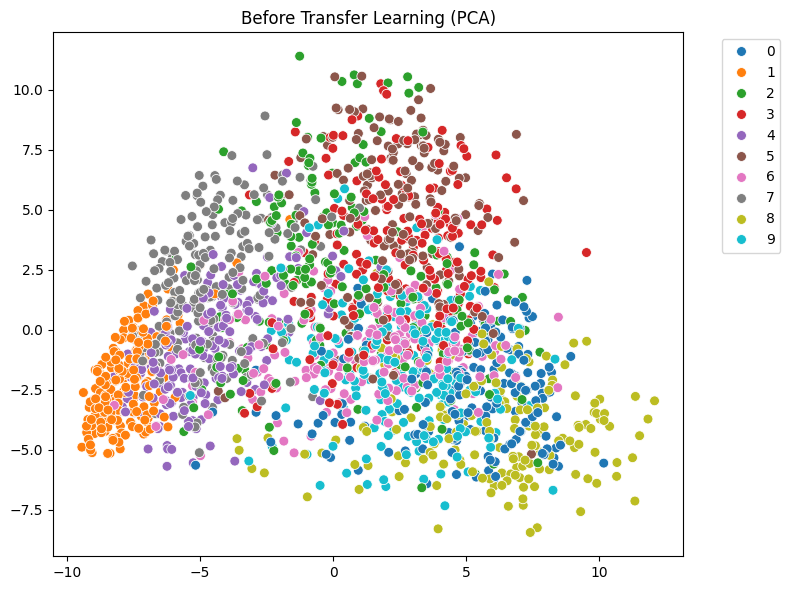

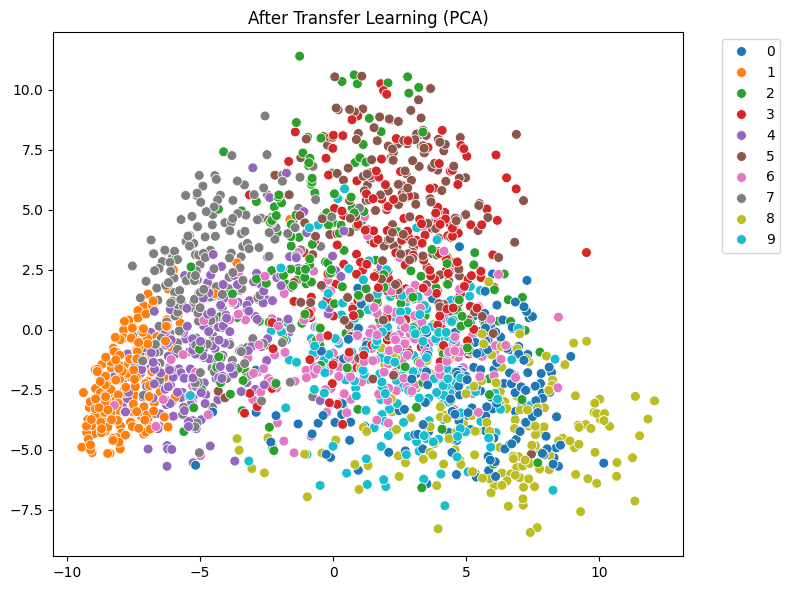

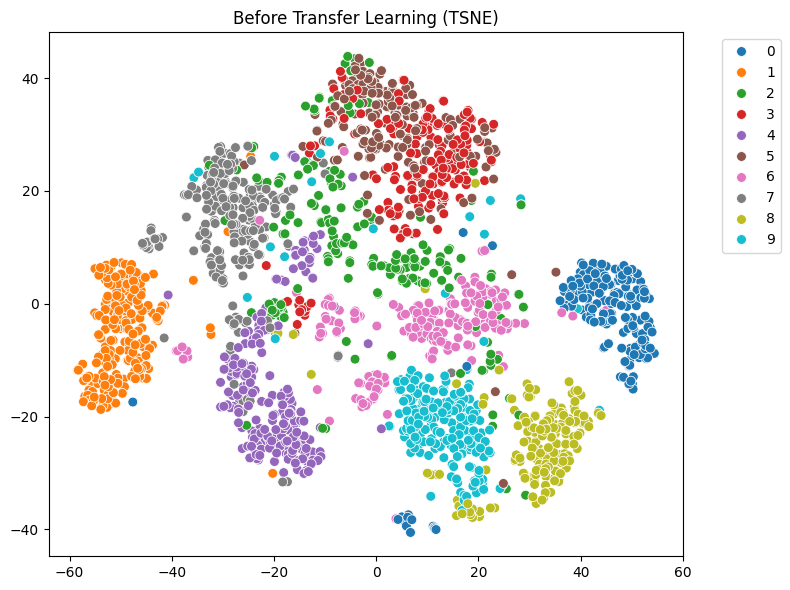

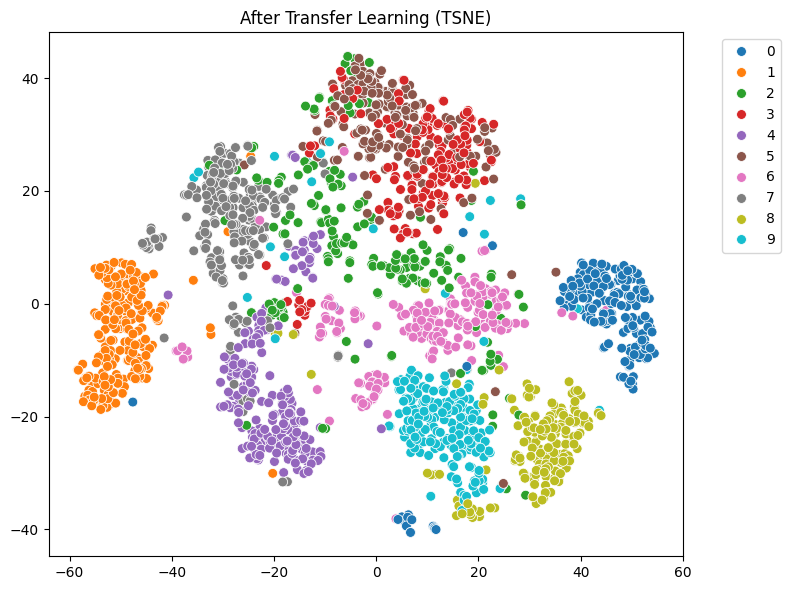

/home/miju_chowdhury/Documents/tf-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/miju_chowdhury/Documents/tf-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


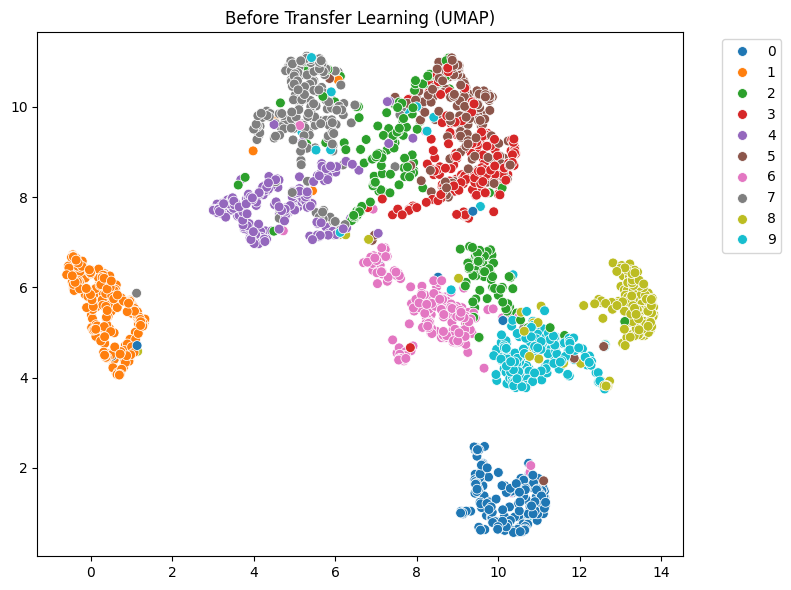

/home/miju_chowdhury/Documents/tf-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/miju_chowdhury/Documents/tf-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


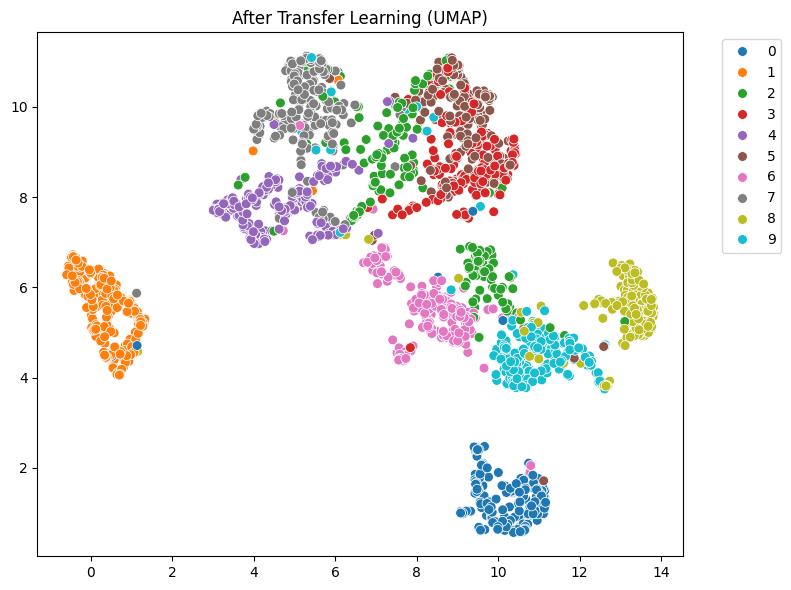

In [12]:
for method in ['pca', 'tsne', 'umap']:
    plot_dim_reduction(features_before, y_sample, method, title="Before Transfer Learning")
    plot_dim_reduction(features_after, y_sample, method, title="After Transfer Learning")
